In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import ExperimentConfig
from utils.data_utils.generator import RFMixtureGenerator, QPSKConfig, NoiseConfig, MixtureConfig
from utils.model_utils.symbol_utils import rrc_taps, recover_symbols_from_waveform, symbol_accuracy
from utils.model_utils.conversion_helpers import complex_to_2ch, complex_matrix_to_iq_channels

from networks.iq_cnn_separator import IQCNNSeparator

# Use cuda if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load the model and the generator
model = IQCNNSeparator(in_ch=2, out_ch=4).to(device)
model.load_state_dict(torch.load("pytorch_models/IQ_CNN_1_channel.pt", map_location=device))
model.eval()

gen = RFMixtureGenerator(seed=0)

/tmp/ipykernel_3913441/592867951.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("pytorch_models/IQ_CNN_1_channel.pt", map_location=devi

### Experiment C

In [3]:
# Set number of receive channles
current_num_channles = 1

qpsk_cfg_soi = QPSKConfig (
    n_symbols=100,
    samples_per_symbol=2,
    rolloff=0.25,
    rrc_span_symbols=12,
    num_channels=current_num_channles
)

qpsk_cfg_int = QPSKConfig (
    n_symbols=100,
    samples_per_symbol=2,
    rolloff=0.25,
    rrc_span_symbols=12,
    num_channels=current_num_channles
)

# Start with single channel case
mix_cfg = MixtureConfig(
    alpha=0.8,
    snr_db=25,
    n_rx=current_num_channles,
    random_phase=False,
    phase_shift_deg=5
)

noise_cfg = NoiseConfig(
    enabled=True
)

# Build matched filter
rrc = rrc_taps(
    sps=2,
    beta=0.25,
    span_symbols=12
)

# thetas = np.arange(0, 2*np.pi, 0.1)
# Degree value of pi/30 is 0.1047 which is really close to 0.1 but yields cleaner restuls
thetas = np.arange(0, 2*np.pi + 0.01, np.pi/30) 
thetas_deg = np.rad2deg(thetas)
all_results = []

num_trials = 10

for i in range(num_trials):
    trial_results = []

    for theta in thetas:
        mix_cfg.interference_phase_shift = theta

        # generate mixture
        ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

        # Prepare input
        if mix_cfg.n_rx == 1:
            x = complex_to_2ch(ex["mixture"])
        else:
            x = complex_matrix_to_iq_channels(ex["mixture"])

        x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

        # Run model
        with torch.no_grad():
            pred = model(x_tensor).squeeze(0).cpu().numpy()
        
        # Convert outputs back to complex waveforms
        pred_a = pred[0] + 1j * pred[1]
        pred_b = pred[2] + 1j * pred[3]
        


        # Recover symbols
        rec_a = recover_symbols_from_waveform(
            pred_a, rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_a"])
        )
        rec_b = recover_symbols_from_waveform(
            pred_b, rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_b"])
        )

        true_a = ex["symbols_a"]
        true_b = ex["symbols_b"]

        # Check both assignemnts and keep the better one

        # Direct assignment
        n_aa = min(len(rec_a), len(true_a))
        n_bb = min(len(rec_b), len(true_b))

        # Swapped assignment
        n_ab = min(len(rec_a), len(true_b))
        n_ba = min(len(rec_b), len(true_a))

        # Mapping 1: (rec_a -> true_a) and (rec_b -> true_a)
        count_a_direct = np.sum(rec_a[:n_aa] == true_a[:n_aa])
        count_b_direct = np.sum(rec_b[:n_bb] == true_b[:n_bb])
        total_direct = count_a_direct + count_b_direct

        # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
        count_a_swapped = np.sum(rec_a[:n_ab] == true_b[:n_ab])
        count_b_swapped = np.sum(rec_b[:n_ba] == true_a[:n_ba])
        total_swapped = count_a_swapped + count_b_swapped

        if total_direct >= total_swapped:
            # Store the count (0-100) for both signals
            soi_count = count_a_direct
            int_count = count_b_direct
        else:
            soi_count = count_b_swapped
            int_count = count_a_swapped

        trial_results.append((soi_count, int_count))

    all_results.append(trial_results)

all_results = np.array(all_results)  # (num_trials, num_thetas, 2)

# Extract means and variances for each signal type
mean_stats = all_results.mean(axis=0)  # Shape: (num_thetas, 2)
var_stats = all_results.var(axis=0)    # Shape: (num_thetas, 2)

mean_soi = mean_stats[:, 0]
mean_int = mean_stats[:, 1]

var_soi = var_stats[:, 0]
var_int = var_stats[:, 1]

# Print the Mean and the Variance 
print(f"{'Phase (deg)':<12} | {'SOI Mean':<10} | {'SOI Var':<10} | {'Int Mean':<10} | {'Int Var':<10}")
print("-" * 70)

# Print every 5th element to keep the console clean. Round deg values to make output cleaner
for i in range(len(thetas_deg))[::5]: 
    # Rounding to 0 decimal places for a "nice" look while maintaining 0.1 rad steps
    print(f"{round(thetas_deg[i]):12d} | {mean_soi[i]:10.2f} | {var_soi[i]:10.2f} | {mean_int[i]:10.2f} | {var_int[i]:10.2f}")


Phase (deg)  | SOI Mean   | SOI Var    | Int Mean   | Int Var   
----------------------------------------------------------------------
           0 |     100.00 |       0.00 |     100.00 |       0.00
          30 |     100.00 |       0.00 |     100.00 |       0.00
          60 |      99.90 |       0.09 |      99.90 |       0.09
          90 |      99.70 |       0.21 |      99.70 |       0.21
         120 |      99.80 |       0.16 |      99.80 |       0.16
         150 |      99.80 |       0.16 |      99.80 |       0.16
         180 |      99.80 |       0.16 |      99.80 |       0.16
         210 |     100.00 |       0.00 |     100.00 |       0.00
         240 |      99.50 |       0.25 |      99.50 |       0.25
         270 |      99.60 |       0.24 |      99.60 |       0.24
         300 |      99.30 |       1.01 |      99.30 |       1.01
         330 |      99.20 |       1.56 |      99.30 |       1.41
         360 |      99.30 |       0.41 |      99.10 |       0.69


#### Plot Results

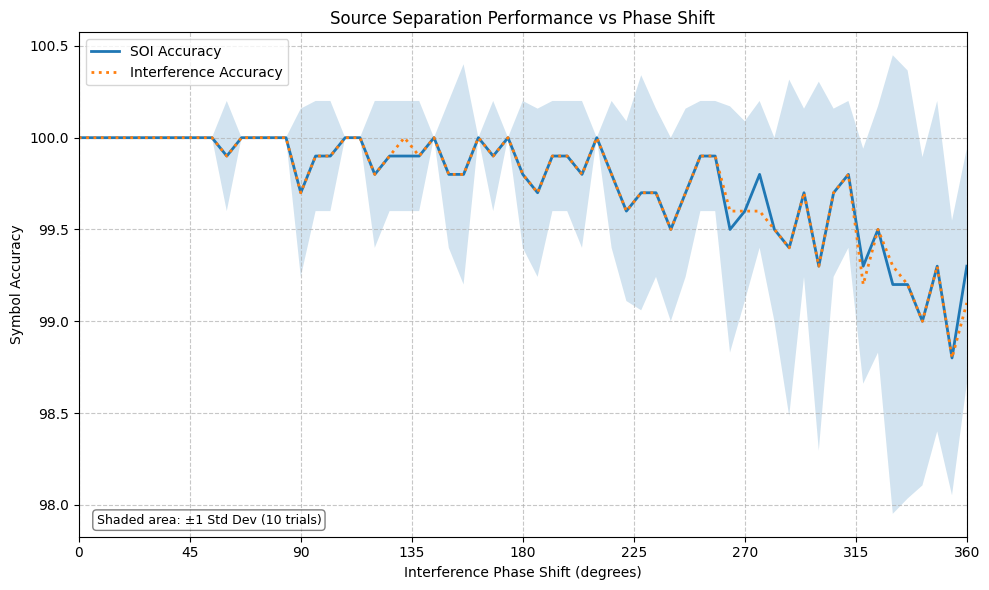

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot using the degree vector
plt.plot(thetas_deg, mean_soi, label='SOI Accuracy', linewidth=2)
plt.plot(thetas_deg, mean_int, label='Interference Accuracy', ls=':', linewidth=2)

# Fill variance (remember to use the degree vector here too)
plt.fill_between(
    thetas_deg, 
    mean_soi - np.sqrt(var_soi), 
    mean_soi + np.sqrt(var_soi), 
    alpha=0.2
)

# Set the x-axis to standard degree increments
plt.xticks(np.arange(0, 361, 45)) 
plt.xlim(0, 360)

plt.xlabel('Interference Phase Shift (degrees)')
plt.ylabel('Symbol Accuracy')
plt.title('Source Separation Performance vs Phase Shift of Interference Signal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('phase_sweep_results.png') 

# Add the note using transform=ax.transAxes to keep it in the corner without resizing the plot
ax = plt.gca()
ax.text(0.02, 0.02, 'Shaded area: ±1 Std Dev (10 trials)', 
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.show()

#### Interpret Results

The line in the above plot represents the mean symbol accuracy over phase shifts.

The blue fill region represents the standard deviation 

When the config file has noise_enabled = False symbol accuracy is 100% for all interference phase shifts. When the noise is enabled we still get above 98% for all phase shifts. This tells us the the changes that we see in symbol accuracy are more because of the random generation of the noise then the phase shift.

### Experiment D

In [5]:
# Set number of receive channles
current_num_channles = 1

# fs = samples per symbol for this experiment
fs_values = np.array([1] + list(range(10, 101, 10)))
all_results = []

num_trials = 10

for i in range(num_trials):
    trial_results = []

    for fs in fs_values:
        qpsk_cfg_soi = QPSKConfig (
            n_symbols=1,
            samples_per_symbol=fs,
            rolloff=0.25,
            rrc_span_symbols=12,
            num_channels=current_num_channles
        )

        qpsk_cfg_int = QPSKConfig (
            n_symbols=1,
            samples_per_symbol=fs,
            rolloff=0.25,
            rrc_span_symbols=12,
            num_channels=current_num_channles
        )

        # Start with single channel case
        mix_cfg = MixtureConfig(
            alpha=0.8,
            snr_db=25,
            n_rx=current_num_channles,
            random_phase=False,
            phase_shift_deg=5
        )

        noise_cfg = NoiseConfig(
            enabled=True
        )

        # Build matched filter
        rrc = rrc_taps(
            sps=fs,
            beta=0.25,
            span_symbols=12
        )

        # generate mixture
        ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

        # Prepare input
        if mix_cfg.n_rx == 1:
            x = complex_to_2ch(ex["mixture"])
        else:
            x = complex_matrix_to_iq_channels(ex["mixture"])

        x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

        # Run model
        with torch.no_grad():
            pred = model(x_tensor).squeeze(0).cpu().numpy()
        
        # Convert outputs back to complex waveforms
        pred_a = pred[0] + 1j * pred[1]
        pred_b = pred[2] + 1j * pred[3]
        

        # Recover symbols
        rec_a = recover_symbols_from_waveform(
            pred_a, rrc, fs, len(ex["symbols_a"])
        )
        rec_b = recover_symbols_from_waveform(
            pred_b, rrc, fs, len(ex["symbols_b"])
        )

        true_a = ex["symbols_a"]
        true_b = ex["symbols_b"]

        # Check both assignemnts and keep the better one

        # Direct assignment
        n_aa = min(len(rec_a), len(true_a))
        n_bb = min(len(rec_b), len(true_b))

        # Swapped assignment
        n_ab = min(len(rec_a), len(true_b))
        n_ba = min(len(rec_b), len(true_a))

        # Mapping 1: (rec_a -> true_a) and (rec_b -> true_a)
        count_a_direct = np.sum(rec_a[:n_aa] == true_a[:n_aa])
        count_b_direct = np.sum(rec_b[:n_bb] == true_b[:n_bb])
        total_direct = count_a_direct + count_b_direct

        # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
        count_a_swapped = np.sum(rec_a[:n_ab] == true_b[:n_ab])
        count_b_swapped = np.sum(rec_b[:n_ba] == true_a[:n_ba])
        total_swapped = count_a_swapped + count_b_swapped

        if total_direct >= total_swapped:
            # Store the count (0-1) for both signals
            soi_count = count_a_direct
            int_count = count_b_direct
        else:
            soi_count = count_b_swapped
            int_count = count_a_swapped

        trial_results.append((soi_count, int_count))

    all_results.append(trial_results)

all_results = np.array(all_results)  # (num_trials, num_fs, 2)

# Extract means and variances for each signal type
mean_stats = all_results.mean(axis=0)  # Shape: (num_fs, 2)
var_stats = all_results.var(axis=0)    # Shape: (num_fs, 2)

mean_soi = mean_stats[:, 0]
mean_int = mean_stats[:, 1]

var_soi = var_stats[:, 0]
var_int = var_stats[:, 1]

# Print the Mean and the Variance 
print(f"{'fs':<12} | {'SOI Mean':<10} | {'SOI Var':<10} | {'Int Mean':<10} | {'Int Var':<10}")
print("-" * 70)

# Print every element since there are only a few fs values
for i in range(len(fs_values)): 
    print(f"{fs_values[i]:12d} | {mean_soi[i]:10.2f} | {var_soi[i]:10.2f} | {mean_int[i]:10.2f} | {var_int[i]:10.2f}")

fs           | SOI Mean   | SOI Var    | Int Mean   | Int Var   
----------------------------------------------------------------------
           1 |       0.50 |       0.25 |       0.30 |       0.21
          10 |       0.50 |       0.25 |       0.60 |       0.24
          20 |       0.60 |       0.24 |       0.50 |       0.25
          30 |       0.60 |       0.24 |       0.30 |       0.21
          40 |       0.50 |       0.25 |       0.50 |       0.25
          50 |       0.20 |       0.16 |       0.50 |       0.25
          60 |       0.40 |       0.24 |       0.30 |       0.21
          70 |       0.30 |       0.21 |       0.60 |       0.24
          80 |       0.20 |       0.16 |       0.70 |       0.21
          90 |       0.50 |       0.25 |       0.50 |       0.25
         100 |       0.60 |       0.24 |       0.30 |       0.21


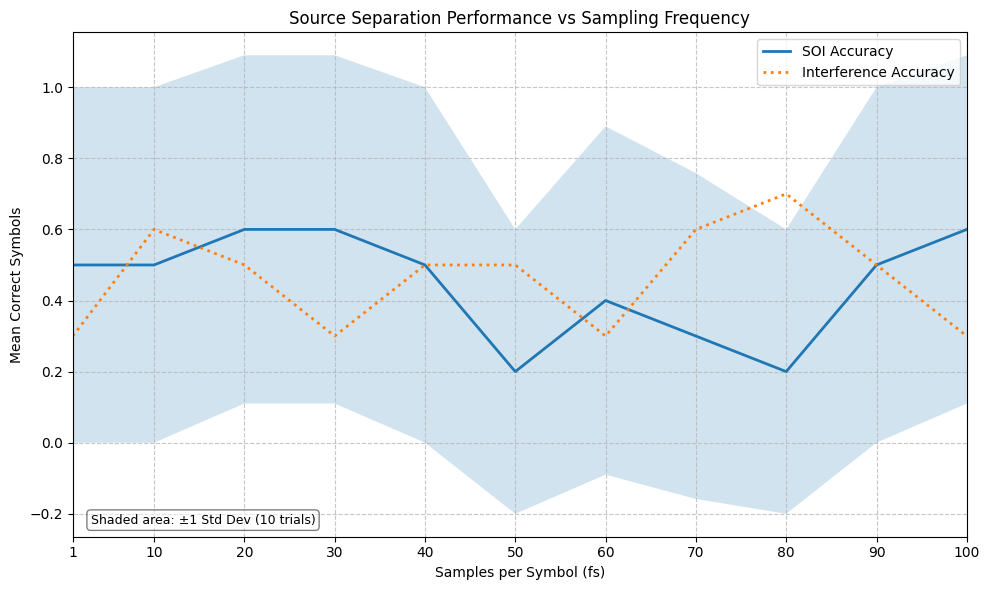

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot using the fs vector
plt.plot(fs_values, mean_soi, label='SOI Accuracy', linewidth=2)
plt.plot(fs_values, mean_int, label='Interference Accuracy', ls=':', linewidth=2)

# Fill variance (remember to use the fs vector here too)
plt.fill_between(
    fs_values, 
    mean_soi - np.sqrt(var_soi), 
    mean_soi + np.sqrt(var_soi), 
    alpha=0.2
)

# Set the x-axis to standard fs increments
plt.xticks(fs_values) 
plt.xlim(fs_values[0], fs_values[-1])

plt.xlabel('Samples per Symbol (fs)')
plt.ylabel('Mean Correct Symbols')
plt.title('Source Separation Performance vs Sampling Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('fs_sweep_results.png') 

# Add the note using transform=ax.transAxes to keep it in the corner without resizing the plot
ax = plt.gca()
ax.text(0.02, 0.02, 'Shaded area: ±1 Std Dev (10 trials)', 
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.show()

#### Interpret Results

The line in the above plot represents the mean symbol accuracy over phase shifts.

The blue fill region represents the standard deviation 

This plot shows us that the number of symbols (spatial information) is critically important. Because the model was training on symbol sequences of size 100 and a sampling frequency of 2, reducing the symbol size hurts preformance drastically. Even when our sampling frequency is 2, like it was in the trained model, because the number of symbols is different than what was trained on results are abysmal. 

#### Experiment E

In [ ]:
# Set number of receive channles
current_num_channles = 1

# T1 and T2 values for this experiment
T_values = np.arange(0.1, 2.0 + 0.01, 0.1)

# Map T values to integer samples per symbol
# Example: 0.1 -> 1, 0.2 -> 2, ..., 2.0 -> 20
sps_values = (T_values * 10).astype(int)

mean_table_soi = np.zeros((len(T_values), len(T_values)))
var_table_soi = np.zeros((len(T_values), len(T_values)))

mean_table_int = np.zeros((len(T_values), len(T_values)))
var_table_int = np.zeros((len(T_values), len(T_values)))

num_trials = 10

for t1_idx, sps_soi in enumerate(sps_values):
    for t2_idx, sps_int in enumerate(sps_values):
        all_results = []

        for i in range(num_trials):
            qpsk_cfg_soi = QPSKConfig (
                n_symbols=100,
                samples_per_symbol=sps_soi,
                rolloff=0.25,
                rrc_span_symbols=12,
                num_channels=current_num_channles
            )

            qpsk_cfg_int = QPSKConfig (
                n_symbols=100,
                samples_per_symbol=sps_int,
                rolloff=0.25,
                rrc_span_symbols=12,
                num_channels=current_num_channles
            )

            # Start with single channel case
            mix_cfg = MixtureConfig(
                alpha=0.8,
                snr_db=25,
                n_rx=current_num_channles,
                random_phase=False,
                phase_shift_deg=5
            )

            noise_cfg = NoiseConfig(
                enabled=True
            )

            # Build matched filter
            rrc_soi = rrc_taps(
                sps=sps_soi,
                beta=0.25,
                span_symbols=12
            )

            rrc_int = rrc_taps(
                sps=sps_int,
                beta=0.25,
                span_symbols=12
            )

            # generate mixture
            ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

            # Prepare input
            if mix_cfg.n_rx == 1:
                x = complex_to_2ch(ex["mixture"])
            else:
                x = complex_matrix_to_iq_channels(ex["mixture"])

            x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

            # Run model
            with torch.no_grad():
                pred = model(x_tensor).squeeze(0).cpu().numpy()
            
            # Convert outputs back to complex waveforms
            pred_a = pred[0] + 1j * pred[1]
            pred_b = pred[2] + 1j * pred[3]
            

            # Recover symbols
            rec_a_soi = recover_symbols_from_waveform(
                pred_a, rrc_soi, sps_soi, len(ex["symbols_a"])
            )
            rec_b_int = recover_symbols_from_waveform(
                pred_b, rrc_int, sps_int, len(ex["symbols_b"])
            )

            rec_a_int = recover_symbols_from_waveform(
                pred_a, rrc_int, sps_int, len(ex["symbols_b"])
            )
            rec_b_soi = recover_symbols_from_waveform(
                pred_b, rrc_soi, sps_soi, len(ex["symbols_a"])
            )

            true_a = ex["symbols_a"]
            true_b = ex["symbols_b"]

            # Check both assignemnts and keep the better one

            # Direct assignment
            n_aa = min(len(rec_a_soi), len(true_a))
            n_bb = min(len(rec_b_int), len(true_b))

            # Swapped assignment
            n_ab = min(len(rec_a_int), len(true_b))
            n_ba = min(len(rec_b_soi), len(true_a))

            # Mapping 1: (rec_a -> true_a) and (rec_b -> true_b)
            count_a_direct = np.sum(rec_a_soi[:n_aa] == true_a[:n_aa])
            count_b_direct = np.sum(rec_b_int[:n_bb] == true_b[:n_bb])
            total_direct = count_a_direct + count_b_direct

            # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
            count_a_swapped = np.sum(rec_a_int[:n_ab] == true_b[:n_ab])
            count_b_swapped = np.sum(rec_b_soi[:n_ba] == true_a[:n_ba])
            total_swapped = count_a_swapped + count_b_swapped

            if total_direct >= total_swapped:
                # Store the count (0-100) for both signals
                soi_count = count_a_direct
                int_count = count_b_direct
            else:
                soi_count = count_b_swapped
                int_count = count_a_swapped

            all_results.append((soi_count, int_count))

        all_results = np.array(all_results)  # (num_trials, 2)

        # Extract means and variances for each signal type
        mean_stats = all_results.mean(axis=0)  # Shape: (2,)
        var_stats = all_results.var(axis=0)    # Shape: (2,)

        mean_table_soi[t1_idx, t2_idx] = mean_stats[0]
        var_table_soi[t1_idx, t2_idx] = var_stats[0]

        mean_table_int[t1_idx, t2_idx] = mean_stats[1]
        var_table_int[t1_idx, t2_idx] = var_stats[1]

# # Print the Mean table for SOI
# print("SOI Mean Table (rows=T1, cols=T2)")
# print("      ", end="")
# for T2 in T_values:
    # print(f"{T2:>8.1f}", end="")
# print()
# print("-" * (6 + 8 * len(T_values)))

# for i, T1 in enumerate(T_values):
    # print(f"{T1:>5.1f} ", end="")
    # for j in range(len(T_values)):
        # print(f"{mean_table_soi[i, j]:8.2f}", end="")
    # print()

# print("\n")

# # Print the Variance table for SOI
# print("SOI Variance Table (rows=T1, cols=T2)")
# print("      ", end="")
# for T2 in T_values:
    # print(f"{T2:>8.1f}", end="")
# print()
# print("-" * (6 + 8 * len(T_values)))

# for i, T1 in enumerate(T_values):
    # print(f"{T1:>5.1f} ", end="")
    # for j in range(len(T_values)):
        # print(f"{var_table_soi[i, j]:8.2f}", end="")
    # print()

# print("\n")

# # Print the Mean table for Interference
# print("Interference Mean Table (rows=T1, cols=T2)")
# print("      ", end="")
# for T2 in T_values:
    # print(f"{T2:>8.1f}", end="")
# print()
# print("-" * (6 + 8 * len(T_values)))

# for i, T1 in enumerate(T_values):
    # print(f"{T1:>5.1f} ", end="")
    # for j in range(len(T_values)):
        # print(f"{mean_table_int[i, j]:8.2f}", end="")
    # print()

# print("\n")

# # Print the Variance table for Interference
# print("Interference Variance Table (rows=T1, cols=T2)")
# print("      ", end="")
# for T2 in T_values:
    # print(f"{T2:>8.1f}", end="")
# print()
# print("-" * (6 + 8 * len(T_values)))

# for i, T1 in enumerate(T_values):
    # print(f"{T1:>5.1f} ", end="")
    # for j in range(len(T_values)):
        # print(f"{var_table_int[i, j]:8.2f}", end="")
    # print()

SOI Mean Table (rows=T1, cols=T2)
           0.1     0.2     0.3     0.4     0.5     0.6     0.7     0.8     0.9     1.0     1.1     1.2     1.3     1.4     1.5     1.6     1.7     1.8     1.9     2.0
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
  0.1    48.80   26.70   27.70   24.60   24.80   28.00   27.10   26.80   27.80   25.60   27.70   25.70   28.10   26.00   26.10   27.80   24.50   29.20   25.30   26.70
  0.2    99.40   99.90   26.00   23.60   27.30   27.30   24.90   29.00   26.60   23.90   26.10   26.70   24.30   26.20   26.40   24.90   26.10   28.00   25.20   27.50
  0.3    88.70   83.80   78.90   25.80   25.30   24.50   26.20   25.00   26.50   25.20   24.30   26.10   27.60   25.00   25.90   23.70   27.40   27.30   27.90   28.70
  0.4    97.60   93.50   93.60   89.60   24.90   26.80   25.50   27.80   25.50   25.50   24.60   26.60   25.50   26.60   23.70   24

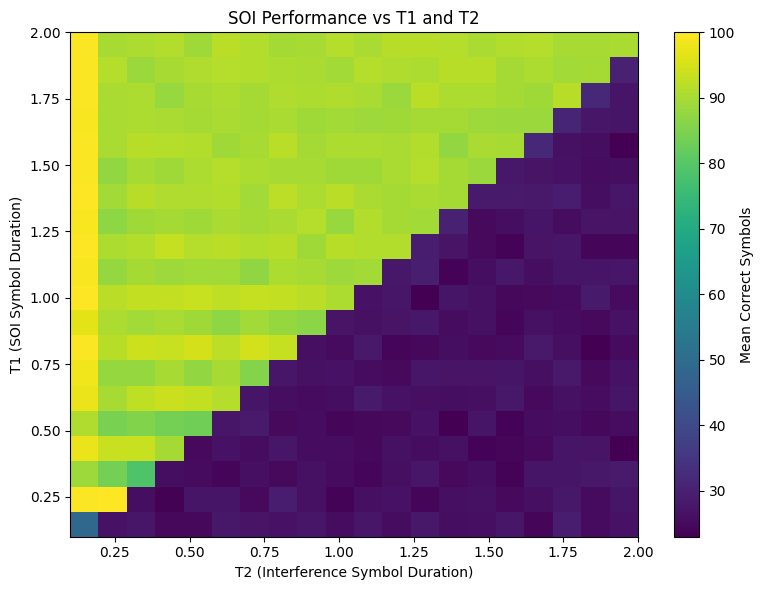

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

im = plt.imshow(
    mean_table_soi,
    origin='lower',
    aspect='auto',
    extent=[T_values[0], T_values[-1], T_values[0], T_values[-1]]
)

plt.colorbar(im, label='Mean Correct Symbols')

plt.xlabel('T2 (Interference Symbol Duration)')
plt.ylabel('T1 (SOI Symbol Duration)')
plt.title('SOI Performance vs T1 and T2')

plt.grid(False)
plt.tight_layout()
plt.show()

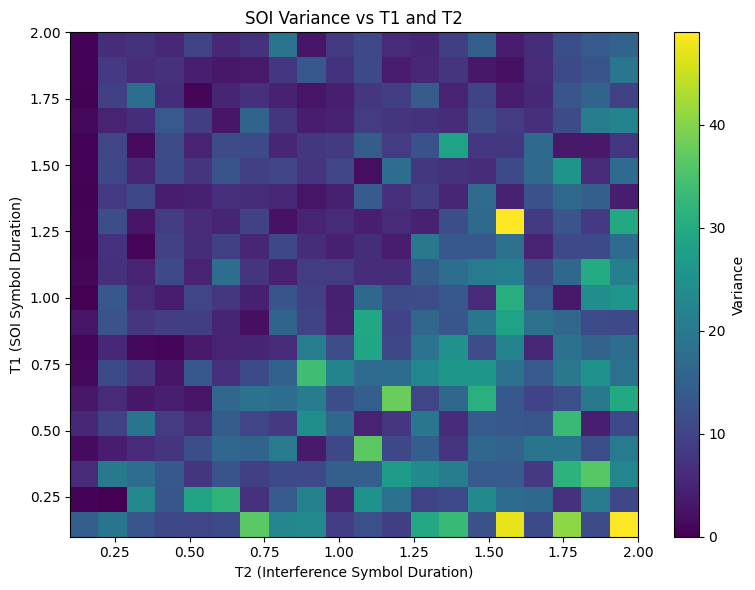

In [9]:
plt.figure(figsize=(8, 6))

im = plt.imshow(
    var_table_soi,
    origin='lower',
    aspect='auto',
    extent=[T_values[0], T_values[-1], T_values[0], T_values[-1]]
)

plt.colorbar(im, label='Variance')

plt.xlabel('T2 (Interference Symbol Duration)')
plt.ylabel('T1 (SOI Symbol Duration)')
plt.title('SOI Variance vs T1 and T2')

plt.tight_layout()
plt.show()

#### Interpret Results

The system exhibits clear assymetry when comparing symbol durations. Whenever our signal of interest has a higher sampling rate the model gets a very high symbol recovery. When the interference signal has a higher sampling rate the model gets very poor symbol recovery.

This leads us to belive that our sepearator relies heavily on temporal resolution (comparitive sampling frequency) and has a clear bias towards signals that are sampled more.